In [1]:
import pandas as pd
import numpy as np
# import pandas_ta
import ta
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_1min = pd.read_csv( "C:/Users/DELL/Desktop/UOIT/capstone/AMZN_alpha_1min_2024-05_to_2025-05.csv")
df_2min = pd.read_csv( "C:/Users/DELL/Desktop/UOIT/capstone/AMZN_alpha_2min_2024-05_to_2025-05.csv")

In [3]:
#Convert 'Timestamp' from object to datetime.
df_1min['Timestamp'] = pd.to_datetime(df_1min['Timestamp'])
df_2min['Timestamp'] = pd.to_datetime(df_2min['Timestamp'])
#check if it is  converted
print( "the data type of 'Timestamp' in 1min dataset is", df_1min['Timestamp'].dtype)
print( "the data type of 'Timestamp' in 2min dataset is", df_2min['Timestamp'].dtype)

the data type of 'Timestamp' in 1min dataset is datetime64[ns]
the data type of 'Timestamp' in 2min dataset is datetime64[ns]


In [4]:
df_1min.info()
df_2min.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236744 entries, 0 to 236743
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Timestamp  236744 non-null  datetime64[ns]
 1   Open       236744 non-null  float64       
 2   High       236744 non-null  float64       
 3   Low        236744 non-null  float64       
 4   Close      236744 non-null  float64       
 5   Volume     236744 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 10.8 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119542 entries, 0 to 119541
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Timestamp  119542 non-null  datetime64[ns]
 1   Open       119542 non-null  float64       
 2   High       119542 non-null  float64       
 3   Low        119542 non-null  float64       
 4   Close      119542 non-null  float

In [5]:
# # Define regular trading hours
# import datetime
# market_open = datetime.time(9, 30)
# market_close = datetime.time(16, 0)

# # Keep only rows within regular trading hours
# df = df[
#     (df['Timestamp'].dt.time >= market_open) & 
#     (df['Timestamp'].dt.time <= market_close)
# ].copy()


In [6]:
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#

In [7]:
# Feature Engineering for 1-Minute Data
def rci(series, period=9):
    result = np.full(len(series), np.nan)
    for i in range(period-1, len(series)):
        price = series[i-period+1:i+1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1  # rank
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff**2)) / (period * (period**2 - 1))) * 100
        result[i] = rci_value
    return result

def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

def cmo(series, window=14):
    diff = series.diff()
    up = diff.clip(lower=0).fillna(0)
    down = -diff.clip(upper=0).fillna(0)
    sum_up = up.rolling(window=window).sum()
    sum_down = down.rolling(window=window).sum()
    cmo_val = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo_val


# Feature Engineering for 1-Minute Data

df_1min['RCI_9'] = rci(df_1min['Close'], period=9)

macd_1 = ta.trend.macd(df_1min['Close'], window_slow=26, window_fast=12)
macd_signal_1 = ta.trend.macd_signal(df_1min['Close'], window_slow=26, window_fast=12, window_sign=9)
df_1min['MACD'] = macd_1
df_1min['MACD_signal'] = macd_signal_1
df_1min['MACD_hist'] = macd_1 - macd_signal_1

df_1min['RSI'] = ta.momentum.rsi(df_1min['Close'], window=7, fillna=True)
df_1min['WilliamsR'] = ta.momentum.williams_r(df_1min['High'], df_1min['Low'], df_1min['Close'], lbp=14, fillna=True)
df_1min['PPO'] = ta.momentum.ppo(df_1min['Close'], window_slow=26, window_fast=12, window_sign=9, fillna=True)
df_1min['Stoch_K'] = ta.momentum.stoch(df_1min['High'], df_1min['Low'], df_1min['Close'], window=14, smooth_window=3, fillna=True)

df_1min['CMF'] = chaikin_money_flow(df_1min, window=20)

df_1min['PSAR'] = ta.trend.PSARIndicator(
    high=df_1min['High'],
    low=df_1min['Low'],
    close=df_1min['Close'],
    step=0.02,
    max_step=0.2
).psar()

bb_length = 20
bb_std = 2
df_1min['BB_Middle'] = df_1min['Close'].rolling(window=bb_length).mean()
df_1min['BB_Std'] = df_1min['Close'].rolling(window=bb_length).std()
df_1min['BB_Upper'] = df_1min['BB_Middle'] + bb_std * df_1min['BB_Std']
df_1min['BB_Lower'] = df_1min['BB_Middle'] - bb_std * df_1min['BB_Std']

sma_length = 20
df_1min['SMA'] = df_1min['Close'].rolling(window=sma_length).mean()

ma_length = 20
envelope_pct = 0.02
df_1min['SMA_Envelope'] = df_1min['Close'].rolling(window=ma_length).mean()
df_1min['Upper_Envelope'] = df_1min['SMA_Envelope'] * (1 + envelope_pct)
df_1min['Lower_Envelope'] = df_1min['SMA_Envelope'] * (1 - envelope_pct)

df_1min['Median_Price'] = (df_1min['High'] + df_1min['Low']) / 2
df_1min['AO'] = df_1min['Median_Price'].rolling(window=5).mean() - df_1min['Median_Price'].rolling(window=34).mean()

df_1min['CMO'] = cmo(df_1min['Close'], window=14)

std_length = 20
df_1min['SMA_Std'] = df_1min['Close'].rolling(window=std_length).mean()
df_1min['STD_Std'] = df_1min['Close'].rolling(window=std_length).std()

ichimoku_1 = ta.trend.IchimokuIndicator(
    high=df_1min['High'],
    low=df_1min['Low'],
    window1=9,
    window2=26,
    window3=52,
    visual=False
)
df_1min['Tenkan_Sen'] = ichimoku_1.ichimoku_conversion_line()
df_1min['Kijun_Sen'] = ichimoku_1.ichimoku_base_line()
df_1min['Senkou_Span_A'] = ichimoku_1.ichimoku_a()
df_1min['Senkou_Span_B'] = ichimoku_1.ichimoku_b()
df_1min['Chikou_Span'] = df_1min['Close'].shift(-26)

adx_indicator_1 = ta.trend.ADXIndicator(
    high=df_1min['High'],
    low=df_1min['Low'],
    close=df_1min['Close'],
    window=14,
    fillna=False
)
df_1min['Plus_DI'] = adx_indicator_1.adx_pos()
df_1min['Minus_DI'] = adx_indicator_1.adx_neg()
df_1min['ADX'] = adx_indicator_1.adx()

df_1min['IBS'] = (df_1min['Close'] - df_1min['Low']) / (df_1min['High'] - df_1min['Low'])


In [8]:
# Feature Engineering for 2-Minute Data

df_2min['RCI_9'] = rci(df_2min['Close'], period=9)

macd_2 = ta.trend.macd(df_2min['Close'], window_slow=26, window_fast=12)
macd_signal_2 = ta.trend.macd_signal(df_2min['Close'], window_slow=26, window_fast=12, window_sign=9)
df_2min['MACD'] = macd_2
df_2min['MACD_signal'] = macd_signal_2
df_2min['MACD_hist'] = macd_2 - macd_signal_2

df_2min['RSI'] = ta.momentum.rsi(df_2min['Close'], window=7, fillna=True)
df_2min['WilliamsR'] = ta.momentum.williams_r(df_2min['High'], df_2min['Low'], df_2min['Close'], lbp=14, fillna=True)
df_2min['PPO'] = ta.momentum.ppo(df_2min['Close'], window_slow=26, window_fast=12, window_sign=9, fillna=True)
df_2min['Stoch_K'] = ta.momentum.stoch(df_2min['High'], df_2min['Low'], df_2min['Close'], window=14, smooth_window=3, fillna=True)
df_2min['CMF'] = chaikin_money_flow(df_2min, window=20)
df_2min['PSAR'] = ta.trend.PSARIndicator(
    high=df_2min['High'],
    low=df_2min['Low'],
    close=df_2min['Close'],
    step=0.02,
    max_step=0.2
).psar()

bb_length = 20
bb_std = 2
df_2min['BB_Middle'] = df_2min['Close'].rolling(window=bb_length).mean()
df_2min['BB_Std'] = df_2min['Close'].rolling(window=bb_length).std()
df_2min['BB_Upper'] = df_2min['BB_Middle'] + bb_std * df_2min['BB_Std']
df_2min['BB_Lower'] = df_2min['BB_Middle'] - bb_std * df_2min['BB_Std']

sma_length = 20
df_2min['SMA'] = df_2min['Close'].rolling(window=sma_length).mean()

ma_length = 20
envelope_pct = 0.02
df_2min['SMA_Envelope'] = df_2min['Close'].rolling(window=ma_length).mean()
df_2min['Upper_Envelope'] = df_2min['SMA_Envelope'] * (1 + envelope_pct)
df_2min['Lower_Envelope'] = df_2min['SMA_Envelope'] * (1 - envelope_pct)

df_2min['Median_Price'] = (df_2min['High'] + df_2min['Low']) / 2
df_2min['AO'] = df_2min['Median_Price'].rolling(window=5).mean() - df_2min['Median_Price'].rolling(window=34).mean()

df_2min['CMO'] = cmo(df_2min['Close'], window=14)

std_length = 20
df_2min['SMA_Std'] = df_2min['Close'].rolling(window=std_length).mean()
df_2min['STD_Std'] = df_2min['Close'].rolling(window=std_length).std()

ichimoku_2 = ta.trend.IchimokuIndicator(
    high=df_2min['High'],
    low=df_2min['Low'],
    window1=9,
    window2=26,
    window3=52,
    visual=False
)
df_2min['Tenkan_Sen'] = ichimoku_2.ichimoku_conversion_line()
df_2min['Kijun_Sen'] = ichimoku_2.ichimoku_base_line()
df_2min['Senkou_Span_A'] = ichimoku_2.ichimoku_a()
df_2min['Senkou_Span_B'] = ichimoku_2.ichimoku_b()
df_2min['Chikou_Span'] = df_2min['Close'].shift(-26)

adx_indicator_2 = ta.trend.ADXIndicator(
    high=df_2min['High'],
    low=df_2min['Low'],
    close=df_2min['Close'],
    window=14,
    fillna=False
)
df_2min['Plus_DI'] = adx_indicator_2.adx_pos()
df_2min['Minus_DI'] = adx_indicator_2.adx_neg()
df_2min['ADX'] = adx_indicator_2.adx()

df_2min['IBS'] = (df_2min['Close'] - df_2min['Low']) / (df_2min['High'] - df_2min['Low'])


In [9]:
# drop NaN from both datasets
df_1min = df_1min.dropna().reset_index(drop=True)
df_2min = df_2min.dropna().reset_index(drop=True)

# Check for missing values
print("\nMissing Values:")
print(df_1min.isnull().sum())
print(df_2min.isnull().sum())


Missing Values:
Timestamp         0
Open              0
High              0
Low               0
Close             0
Volume            0
RCI_9             0
MACD              0
MACD_signal       0
MACD_hist         0
RSI               0
WilliamsR         0
PPO               0
Stoch_K           0
CMF               0
PSAR              0
BB_Middle         0
BB_Std            0
BB_Upper          0
BB_Lower          0
SMA               0
SMA_Envelope      0
Upper_Envelope    0
Lower_Envelope    0
Median_Price      0
AO                0
CMO               0
SMA_Std           0
STD_Std           0
Tenkan_Sen        0
Kijun_Sen         0
Senkou_Span_A     0
Senkou_Span_B     0
Chikou_Span       0
Plus_DI           0
Minus_DI          0
ADX               0
IBS               0
dtype: int64
Timestamp         0
Open              0
High              0
Low               0
Close             0
Volume            0
RCI_9             0
MACD              0
MACD_signal       0
MACD_hist         0
RSI       

In [10]:
pd.set_option('display.max_columns', None)  # Show all columns in output
df_2min.head(5)

,Timestamp,Open,High,Low,Close,Volume,RCI_9,MACD,MACD_signal,MACD_hist,RSI,WilliamsR,PPO,Stoch_K,CMF,PSAR,BB_Middle,BB_Std,BB_Upper,BB_Lower,SMA,SMA_Envelope,Upper_Envelope,Lower_Envelope,Median_Price,AO,CMO,SMA_Std,STD_Std,Tenkan_Sen,Kijun_Sen,Senkou_Span_A,Senkou_Span_B,Chikou_Span,Plus_DI,Minus_DI,ADX,IBS
0,2024-05-01 05:06:00,179.07,179.09,178.66,178.66,1895,11.666667,0.331738,0.336288,-0.004550,41.470885,-49.162011,0.185783,50.837989,0.183354,178.391064,178.6395,0.494948,179.629396,177.649604,178.6395,178.6395,182.21229,175.06671,178.875,0.783294,16.129032,178.6395,0.494948,178.930,178.645,178.7875,177.77,179.06,29.162138,20.842306,53.661774,0.000000
1,2024-05-01 05:08:00,178.66,178.70,178.31,178.31,3211,58.333333,0.260576,0.321146,-0.060570,32.301660,-68.715084,0.145945,31.284916,0.121779,179.540000,178.6365,0.496846,179.630191,177.642809,178.6365,178.6365,182.20923,175.06377,178.505,0.565794,5.537459,178.6365,0.496846,178.925,178.645,178.7850,177.77,179.00,26.747614,26.547094,49.855665,0.000000
2,2024-05-01 05:10:00,178.30,178.67,178.27,178.49,1610,91.666667,0.216212,0.300159,-0.083947,40.230670,-66.037736,0.121100,33.962264,0.115978,179.515400,178.6420,0.494460,179.630920,177.653080,178.6420,178.6420,182.21484,175.06916,178.470,0.350029,15.755627,178.6420,0.494460,178.905,178.645,178.7750,177.77,179.12,24.506454,25.160628,46.388625,0.550000
3,2024-05-01 05:12:00,178.55,178.65,178.50,178.60,665,86.666667,0.187765,0.277680,-0.089915,44.837008,-59.119497,0.105165,40.880503,0.116921,179.465584,178.6530,0.490758,179.634515,177.671485,178.6530,178.6530,182.22606,175.07994,178.575,0.189206,18.633540,178.6530,0.490758,178.905,178.645,178.7750,177.77,178.50,23.652737,24.284122,43.169232,0.666667
4,2024-05-01 05:14:00,178.58,178.92,178.56,178.89,1916,71.666667,0.186471,0.259439,-0.072967,55.407423,-49.618321,0.104425,50.381679,0.131880,179.417761,178.6785,0.489073,179.656646,177.700354,178.6785,178.6785,182.25207,175.10493,178.740,0.101088,20.364742,178.6785,0.489073,178.885,178.645,178.7650,177.77,178.97,27.649642,22.393830,40.835893,0.916667


In [11]:
# Get engineered feature columns for df_1min (exclude Timestamp, Open, High, Low, Close, Volume)
exclude_1min = ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
eng_features_1min = [col for col in df_1min.columns if col not in exclude_1min]
print("1-Minute Engineered Features:\n", eng_features_1min)


1-Minute Engineered Features:
 ['RCI_9', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI', 'WilliamsR', 'PPO', 'Stoch_K', 'CMF', 'PSAR', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'SMA', 'SMA_Envelope', 'Upper_Envelope', 'Lower_Envelope', 'Median_Price', 'AO', 'CMO', 'SMA_Std', 'STD_Std', 'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span', 'Plus_DI', 'Minus_DI', 'ADX', 'IBS']


In [12]:
# Get engineered feature columns for df_2min (exclude Timestamp, Open, High, Low, Close, Volume)
exclude_2min = ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
eng_features_2min = [col for col in df_2min.columns if col not in exclude_2min]
print("2-Minute Engineered Features:\n", eng_features_2min)


2-Minute Engineered Features:
 ['RCI_9', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI', 'WilliamsR', 'PPO', 'Stoch_K', 'CMF', 'PSAR', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'SMA', 'SMA_Envelope', 'Upper_Envelope', 'Lower_Envelope', 'Median_Price', 'AO', 'CMO', 'SMA_Std', 'STD_Std', 'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span', 'Plus_DI', 'Minus_DI', 'ADX', 'IBS']


In [13]:

# Resampling
df_1min = df_1min.set_index('Timestamp')
df_2min = df_2min.set_index('Timestamp')

records = []

for ts in df_2min.index[:-1]:  # Exclude last row (no t+1 target)
    row = {}
    ts_1min_t0 = ts
    ts_1min_t1 = ts + pd.Timedelta(minutes=1)
    ts_2min_t0 = ts
    ts_2min_t1 = ts + pd.Timedelta(minutes=2)
    
    # 1min features at t0 and t1
    for f in eng_features_1min:
        row[f'{f}_1min_t0'] = df_1min.at[ts_1min_t0, f] if ts_1min_t0 in df_1min.index else np.nan
        row[f'{f}_1min_t1'] = df_1min.at[ts_1min_t1, f] if ts_1min_t1 in df_1min.index else np.nan
    
    # 2min features at t0
    for f in eng_features_2min:
        row[f'{f}_2min_t0'] = df_2min.at[ts_2min_t0, f] if ts_2min_t0 in df_2min.index else np.nan

    # 2min open/close at t0 (current bar)
    row['Open_2min'] = df_2min.at[ts_2min_t0, 'Open'] if ts_2min_t0 in df_2min.index else np.nan
    row['Close_2min'] = df_2min.at[ts_2min_t0, 'Close'] if ts_2min_t0 in df_2min.index else np.nan

    # 2min open/close at t1 (next bar, for target calculation)
    if ts_2min_t1 in df_2min.index:
        next_open = df_2min.at[ts_2min_t1, 'Open']
        next_close = df_2min.at[ts_2min_t1, 'Close']
        each_return = (next_close - next_open) / next_open
        direction = 1 if next_close > df_2min.at[ts_2min_t0, 'Close'] else 0  # 1 if next Close > current Close, else 0
        row['Return'] = each_return
        row['Direction'] = direction
    else:
        row['Return'] = np.nan
        row['Direction'] = np.nan
    
    row['Timestamp'] = ts  # keep timestamp for reference
    records.append(row)

# Build DataFrame
df = pd.DataFrame(records)
df = df.set_index('Timestamp')

# Drop rows with any NaNs in features or target
# feature_cols = [col for col in df.columns if col not in ['Return', 'Direction']]
# df = df.dropna(subset=feature_cols + ['Return', 'Direction'])




In [14]:
# print("Multi-frame merged dataframe shape:", df.shape)
df.head(10)

,RCI_9_1min_t0,RCI_9_1min_t1,MACD_1min_t0,MACD_1min_t1,MACD_signal_1min_t0,MACD_signal_1min_t1,MACD_hist_1min_t0,MACD_hist_1min_t1,RSI_1min_t0,RSI_1min_t1,WilliamsR_1min_t0,WilliamsR_1min_t1,PPO_1min_t0,PPO_1min_t1,Stoch_K_1min_t0,Stoch_K_1min_t1,CMF_1min_t0,CMF_1min_t1,PSAR_1min_t0,PSAR_1min_t1,BB_Middle_1min_t0,BB_Middle_1min_t1,BB_Std_1min_t0,BB_Std_1min_t1,BB_Upper_1min_t0,BB_Upper_1min_t1,BB_Lower_1min_t0,BB_Lower_1min_t1,SMA_1min_t0,SMA_1min_t1,SMA_Envelope_1min_t0,SMA_Envelope_1min_t1,Upper_Envelope_1min_t0,Upper_Envelope_1min_t1,Lower_Envelope_1min_t0,Lower_Envelope_1min_t1,Median_Price_1min_t0,Median_Price_1min_t1,AO_1min_t0,AO_1min_t1,CMO_1min_t0,CMO_1min_t1,SMA_Std_1min_t0,SMA_Std_1min_t1,STD_Std_1min_t0,STD_Std_1min_t1,Tenkan_Sen_1min_t0,Tenkan_Sen_1min_t1,Kijun_Sen_1min_t0,Kijun_Sen_1min_t1,Senkou_Span_A_1min_t0,Senkou_Span_A_1min_t1,Senkou_Span_B_1min_t0,Senkou_Span_B_1min_t1,Chikou_Span_1min_t0,Chikou_Span_1min_t1,Plus_DI_1min_t0,Plus_DI_1min_t1,Minus_DI_1min_t0,Minus_DI_1min_t1,ADX_1min_t0,ADX_1min_t1,IBS_1min_t0,IBS_1min_t1,RCI_9_2min_t0,MACD_2min_t0,MACD_signal_2min_t0,MACD_hist_2min_t0,RSI_2min_t0,WilliamsR_2min_t0,PPO_2min_t0,Stoch_K_2min_t0,CMF_2min_t0,PSAR_2min_t0,BB_Middle_2min_t0,BB_Std_2min_t0,BB_Upper_2min_t0,BB_Lower_2min_t0,SMA_2min_t0,SMA_Envelope_2min_t0,Upper_Envelope_2min_t0,Lower_Envelope_2min_t0,Median_Price_2min_t0,AO_2min_t0,CMO_2min_t0,SMA_Std_2min_t0,STD_Std_2min_t0,Tenkan_Sen_2min_t0,Kijun_Sen_2min_t0,Senkou_Span_A_2min_t0,Senkou_Span_B_2min_t0,Chikou_Span_2min_t0,Plus_DI_2min_t0,Minus_DI_2min_t0,ADX_2min_t0,IBS_2min_t0,Open_2min,Close_2min,Return,Direction
Timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-01 05:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.666667,0.331738,0.336288,-0.004550,41.470885,-49.162011,0.185783,50.837989,0.183354,178.391064,178.6395,0.494948,179.629396,177.649604,178.6395,178.6395,182.21229,175.06671,178.875,0.783294,16.129032,178.6395,0.494948,178.930,178.645,178.7875,177.770,179.06,29.162138,20.842306,53.661774,0.000000,179.07,178.66,-0.001959,0.0
2024-05-01 05:08:00,81.666667,81.666667,0.116209,0.053538,0.216420,0.183844,-0.100212,-0.130306,23.545540,16.575979,-89.423077,-100.000000,0.064968,0.029938,10.576923,0.000000,0.213612,0.190903,179.490592,179.431156,179.0550,179.0580,0.363832,0.357029,179.782664,179.772057,178.327336,178.343943,179.0550,179.0580,179.0550,179.0580,182.63610,182.63916,175.47390,175.47684,178.590,178.505,0.227971,0.089559,-41.333333,-73.248408,179.0550,179.0580,0.363832,0.357029,178.995,178.880,178.645,178.745,178.8200,178.8125,178.645,178.645,179.15,179.02,20.923841,18.178691,32.602896,34.717146,34.853270,34.597042,0.611111,0.000000,58.333333,0.260576,0.321146,-0.060570,32.301660,-68.715084,0.145945,31.284916,0.121779,179.540000,178.6365,0.496846,179.630191,177.642809,178.6365,178.6365,182.20923,175.06377,178.505,0.565794,5.537459,178.6365,0.496846,178.925,178.645,178.7850,177.770,179.00,26.747614,26.547094,49.855665,0.000000,178.66,178.31,0.001066,1.0
2024-05-01 05:10:00,95.000000,95.000000,0.019782,-0.008486,0.151032,0.119128,-0.131250,-0.127614,32.187992,31.500245,-80.487805,-82.113821,0.011063,-0.004747,19.512195,17.886179,0.186232,0.144267,179.341464,179.234318,179.0635,179.0505,0.347067,0.363889,179.757634,179.778279,178.369366,178.322721,179.0635,179.0505,179.0635,179.0505,182.64477,182.63151,175.48223,175.46949,178.470,178.515,-0.036676,-0.127235,-51.479290,-50.898204,179.0635,179.0505,0.347067,0.363889,178.770,178.740,178.745,178.745,178.7575,178.7425,178.645,178.645,179.10,179.02,15.877805,15.204261,31.588684,30.248677,34.490031,34.390663,0.600000,0.307692,91.666667,0.216212,0.300159,-0.083947,40.230670,-66.037736,0.121100,33.962264,0.115978,17

In [15]:
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

RCI_9_1min_t1          12934
MACD_1min_t1           12934
SMA_Std_1min_t1        12934
MACD_signal_1min_t1    12934
RSI_1min_t1            12934
                       ...  
Minus_DI_1min_t0       12895
ADX_1min_t0            12895
IBS_1min_t0            12895
Return                   528
Direction                528
Length: 66, dtype: int64


In [16]:
print(df.isna().mean().sort_values(ascending=False))


RCI_9_1min_t1          0.116984
MACD_1min_t1           0.116984
MACD_hist_1min_t1      0.116984
MACD_signal_1min_t1    0.116984
SMA_1min_t1            0.116984
                         ...   
Minus_DI_2min_t0       0.000000
IBS_2min_t0            0.000000
ADX_2min_t0            0.000000
Close_2min             0.000000
Open_2min              0.000000
Length: 100, dtype: float64


In [17]:
df = df.reset_index()  # Timestamp is now a column

import datetime

market_open = datetime.time(9, 30)
market_close = datetime.time(16, 0)

# Filter for regular trading hours
df = df[
    (df['Timestamp'].dt.time >= market_open) &
    (df['Timestamp'].dt.time <= market_close)
].copy()

In [18]:

df = df.dropna().reset_index(drop=True)
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp        0
RCI_9_1min_t0    0
RCI_9_1min_t1    0
MACD_1min_t0     0
MACD_1min_t1     0
                ..
IBS_2min_t0      0
Open_2min        0
Close_2min       0
Return           0
Direction        0
Length: 101, dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

non_feature_cols = ['each_return', 'Direction', 'Timestamp']  
feature_cols = [col for col in df.columns if col not in non_feature_cols]


# scaler = StandardScaler()
# df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [20]:
n = len(df)
train_end = int(0.60 * n)
validate_end = int(0.70 * n)  # 70%

df_train = df.iloc[:train_end].reset_index(drop=True)
df_validate = df.iloc[train_end:validate_end].reset_index(drop=True)
df_test  = df.iloc[validate_end:].reset_index(drop=True)

print(f"Train set: {df_train.shape}")
print(f"Validation set: {df_validate.shape}")
print(f"Test set: {df_test.shape}")


Train set: (29400, 101)
Validation set: (4900, 101)
Test set: (14700, 101)


In [21]:
# Target variable name
target = 'Direction'

# X/y for Train
X_train = df_train[feature_cols].values   # eng_features have been defined previously at the cell of Feature Engineering
y_train = df_train[target].values

# X/y for Validation
X_validate = df_validate[feature_cols].values
y_validate = df_validate[target].values

# X/y for Test
X_test = df_test[feature_cols].values
y_test = df_test[target].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_validate: {X_validate.shape}, y_validate: {y_validate.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (29400, 99), y_train: (29400,)
X_validate: (4900, 99), y_validate: (4900,)
X_test: (14700, 99), y_test: (14700,)


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# ANN 
model = Sequential()
model.add(Dense(99, activation='relu', input_shape=(len(feature_cols),))) # number of neurons in input layer is the same as the number of technical indicators
for _ in range(1):  # hidden layers
    model.add(Dense(99, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary output

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy', 'mse'])


# # early stop
early_stop = EarlyStopping(
    monitor='val_accuracy',       
    patience=5,               # stop if no improvement after 5 epochs
    restore_best_weights=True # restores weights from best epoch
)

# train 
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_validate, y_validate),
    callbacks=[early_stop],
    verbose=2
)

# Evaluate on Test
test_loss, test_acc, test_mse = model.evaluate(X_test, y_test)


train_acc = history.history['accuracy'][-1] * 100
train_mse = history.history['mse'][-1]
val_acc = history.history['val_accuracy'][-1] * 100
val_mse = history.history['val_mse'][-1]

print(f"Train Accuracy: {train_acc:.2f}%, Train MSE: {train_mse:.4f}")
print(f"Test Accuracy: {test_acc:.2%}, Test MSE: {test_mse:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%, Validation MSE: {val_mse:.4f}")




Epoch 1/50


D:\Anaconda\envs\notebook-7.3.2\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


230/230 - 2s - 7ms/step - accuracy: 0.4948 - loss: 2.2258 - mse: 0.4031 - val_accuracy: 0.4994 - val_loss: 1.5528 - val_mse: 0.4398
Epoch 2/50
230/230 - 0s - 2ms/step - accuracy: 0.4974 - loss: 1.2115 - mse: 0.3520 - val_accuracy: 0.4976 - val_loss: 1.0422 - val_mse: 0.3678
Epoch 3/50
230/230 - 0s - 2ms/step - accuracy: 0.4967 - loss: 1.2209 - mse: 0.3692 - val_accuracy: 0.4967 - val_loss: 0.7564 - val_mse: 0.2766
Epoch 4/50
230/230 - 0s - 2ms/step - accuracy: 0.4934 - loss: 1.3634 - mse: 0.3594 - val_accuracy: 0.4998 - val_loss: 0.7761 - val_mse: 0.2847
Epoch 5/50
230/230 - 0s - 2ms/step - accuracy: 0.4950 - loss: 0.8300 - mse: 0.3023 - val_accuracy: 0.4998 - val_loss: 0.7540 - val_mse: 0.2765
Epoch 6/50
230/230 - 0s - 2ms/step - accuracy: 0.4962 - loss: 0.8641 - mse: 0.3094 - val_accuracy: 0.4988 - val_loss: 1.0391 - val_mse: 0.3708
Epoch 7/50
230/230 - 0s - 2ms/step - accuracy: 0.4931 - loss: 0.8121 - mse: 0.2964 - val_accuracy: 0.4986 - val_loss: 0.7354 - val_mse: 0.2692
Epoch 8/50

In [25]:
#---------Return Calculation-----------#
#---------Return Calculation-----------#
#---------Return Calculation-----------#


In [41]:

y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)  # Binary prediction: 1=buy, 0=do nothing

df_test['Predicted'] = y_pred

# Returns for all predicted trades
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
total_trade_return = trade_return.sum() 
num_trades = len(trade_return)
average_trade_return = trade_return.mean()

# Win Rate
win_trades = (trade_return > 0).sum()
winrate = win_trades / num_trades if num_trades > 0 else 0

# Average Daily Return
df_test['trading_Date'] = pd.to_datetime(df_test['Timestamp']).dt.date
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
daily_return = trade_date.groupby('trading_Date')['Return'].sum()
average_daily_return = daily_return.mean()

# Cumulative Return
cumulative_return = (np.prod(1 + trade_return) - 1) * 100  # as percent

# Max Drawdown
cumulative = (1 + trade_return).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min() * 100  # as percent

# Output Results
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.4f}")
print(f"Average daily return: {average_daily_return:.4f}")
print(f"Number of trades: {num_trades}")
print(f"Average return per trade: {average_trade_return:.4f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max Drawdown: {max_drawdown:.2f}%")


460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step
Cumulative Return: 50.36%
Total Sum of Return: 0.4158
Average daily return: 0.0055
Number of trades: 6222
Average return per trade: 0.0001
Win rate: 50.82%
Max Drawdown: -6.37%


In [42]:
fee_per_trade = 0.0004

# Predict probabilities or class labels on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)  # Binary prediction: 1=buy, 0=do nothing

df_test['Predicted'] = y_pred

# Returns on predicted trades 
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
trade_return_with_fee = trade_return - fee_per_trade

total_trade_return = trade_return.sum() 
total_trade_return_with_fee = trade_return_with_fee.sum()

num_trades = len(trade_return)
average_trade_return = trade_return.mean()
average_trade_return_with_fee = trade_return_with_fee.mean()

# Win Rate
win_trades = (trade_return > 0).sum()
winrate = win_trades / num_trades if num_trades > 0 else 0

win_trades_with_fee = (trade_return_with_fee > 0).sum()
winrate_with_fee = win_trades_with_fee / num_trades if num_trades > 0 else 0

# Average Daily Return
df_test['trading_Date'] = pd.to_datetime(df_test['Timestamp']).dt.date
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
trade_date_with_fee = trade_date.copy()
trade_date_with_fee['Return'] = trade_return_with_fee.values

daily_return = trade_date.groupby('trading_Date')['Return'].sum()
average_daily_return = daily_return.mean()

daily_return_with_fee = trade_date_with_fee.groupby('trading_Date')['Return'].sum()
average_daily_return_with_fee = daily_return_with_fee.mean()

# Cumulative Return 
cumulative_return = (np.prod(1 + trade_return) - 1) * 100  # as percent
cumulative_return_with_fee = (np.prod(1 + trade_return_with_fee) - 1) * 100

# Max Drawdown Calculation
cumulative = (1 + trade_return).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min() * 100  # as percent

cumulative_with_fee = (1 + trade_return_with_fee).cumprod()
running_max_with_fee = cumulative_with_fee.cummax()
drawdown_with_fee = (cumulative_with_fee - running_max_with_fee) / running_max_with_fee
max_drawdown_with_fee = drawdown_with_fee.min() * 100  # as percent

print("=== No Fee ===")
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.4f}")
print(f"Average daily return: {average_daily_return:.4f}")
print(f"Number of trades: {num_trades}")
print(f"Average return per trade: {average_trade_return:.4f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

print("\n=== With Fee ===")
print(f"Cumulative Return: {cumulative_return_with_fee:.2f}%")
print(f"Total Sum of Return: {total_trade_return_with_fee:.4f}")
print(f"Average daily return: {average_daily_return_with_fee:.4f}")
print(f"Average return per trade: {average_trade_return_with_fee:.4f}")
print(f"Win rate: {winrate_with_fee:.2%}")
print(f"Max Drawdown: {max_drawdown_with_fee:.2f}%")


460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step
=== No Fee ===
Cumulative Return: 50.36%
Total Sum of Return: 0.4158
Average daily return: 0.0055
Number of trades: 6222
Average return per trade: 0.0001
Win rate: 50.82%
Max Drawdown: -6.37%

=== With Fee ===
Cumulative Return: -87.52%
Total Sum of Return: -2.0730
Average daily return: -0.0276
Average return per trade: -0.0003
Win rate: 35.74%
Max Drawdown: -87.94%


In [28]:
print(df_test[['Timestamp', 'Return']].head(10))

            Timestamp    Return
0 2025-01-13 09:30:00 -0.003298
1 2025-01-13 09:32:00 -0.001489
2 2025-01-13 09:34:00 -0.001474
3 2025-01-13 09:36:00  0.000092
4 2025-01-13 09:38:00 -0.001338
5 2025-01-13 09:40:00  0.002459
6 2025-01-13 09:42:00 -0.001105
7 2025-01-13 09:44:00  0.000553
8 2025-01-13 09:46:00  0.002397
9 2025-01-13 09:48:00  0.000867


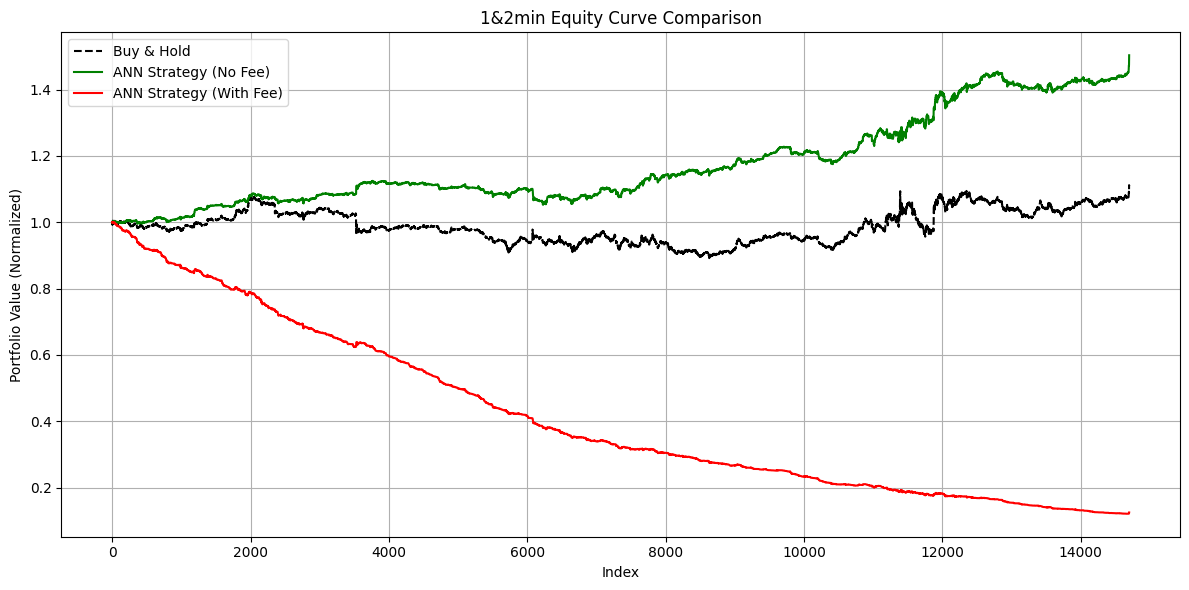

In [44]:

fee_per_trade = 0.0004 
# Make a copy to avoid modifying the original df_test
returns_strategy = np.where(df_test['Predicted'] == 1, df_test['Return'], 0)
returns_strategy_with_fee = np.where(df_test['Predicted'] == 1, df_test['Return'] - fee_per_trade, 0)

# Buy & Hold (every return in the test set)
buy_hold_equity = (1 + df_test['Return']).cumprod()

# ANN Strategy (No Fee): compound only the predicted trades, else flat (i.e., +0)
strategy_equity_no_fee = (1 + returns_strategy).cumprod()

# ANN Strategy (With Fee): same logic, but subtract fee per trade
strategy_equity_with_fee = (1 + returns_strategy_with_fee).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, buy_hold_equity, label='Buy & Hold', linestyle='--', color='black')
plt.plot(df_test.index, strategy_equity_no_fee, label='ANN Strategy (No Fee)', color='green')
plt.plot(df_test.index, strategy_equity_with_fee, label='ANN Strategy (With Fee)', color='red')
plt.title('1&2min Equity Curve Comparison')
plt.xlabel('Date' if isinstance(df_test.index[0], pd.Timestamp) else 'Index')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Confusion Matrix:


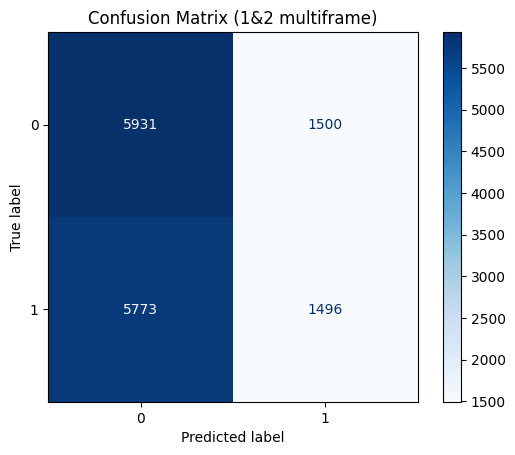


Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.80      0.62      7431
         1.0       0.50      0.21      0.29      7269

    accuracy                           0.51     14700
   macro avg       0.50      0.50      0.46     14700
weighted avg       0.50      0.51      0.46     14700



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# y_test: true labels, y_pred: predicted labels
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (1&2 multiframe)")
plt.show()

# Optional: Show a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


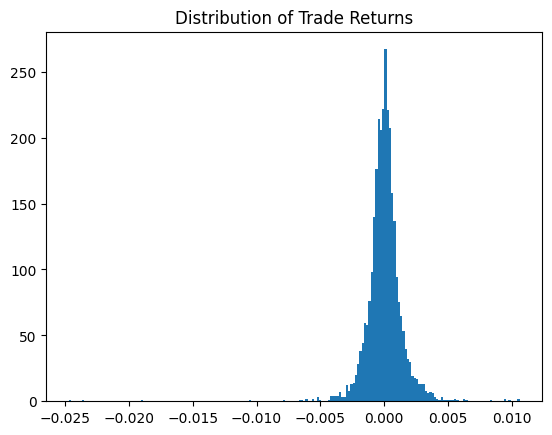

In [32]:
import matplotlib.pyplot as plt
plt.hist(trade_return, bins=200)
plt.title("Distribution of Trade Returns")
plt.show()
